# 1- Importing and matching Data

- Get Parent directory from any location
- Import GEM xml file with original information
- Import firtered Compound Graph

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from etc.parse_ids import XMLParser

# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
data_folder = project_root / "data" / "resources"
Pilot = data_folder / "PilotStudy_All"

# Get graph prevouly fitered
graph_gml = data_folder / "generated" / "modified_graph.gml"
# Get the original graph for matching ids
human1_xml = data_folder / "Human-GEM.xml"

### Consortium sumarized data from different samples
- First we define a method to match the chebis with the HUMAN1
- Then upload data and apply changes

In [2]:
# Auxiliar function to extract the chebi number from a string like "CHEBI:12345"
def extract_single_chebi(value):
    """Extract CHEBI number from a single CHEBI string"""
    if pd.isna(value):
        return None
    match = re.search(r"CHEBI:(\d+)", str(value))
    if match:
        return int(match.group(1))
    return None

In [3]:
# Load the data file as a pandas DataFrame
data_file = pd.read_excel(Pilot / "Daniel_Suplementary_info.xlsx", sheet_name="Sheet1")

# Filter to only include rows where ID_level is 1
data_file = data_file[data_file.ID_level==1]

# Add new column with extracted CHEBI numbers
data_file['CHEBI_number'] = data_file.CHEBI_ID_Step2.apply(extract_single_chebi)

### From HUMAN1 GEM xml file 
- Create a dataframe
- Create colum to match chebis ids and link them with human1 ids

In [4]:
parser = XMLParser(human1_xml)
df = parser.extract_data()
df_human1 = parser.to_identifier_df()
df_human1['Consortium'] = None

### Matching and filling column

In [5]:
# Convert df_human1 CHEBI to integers for matching
df_human1['chebi_int'] = pd.to_numeric(df_human1['chebi'], errors='coerce').astype('Int64')
# Get set of CHEBIs from data_file
data_file_chebis = set(data_file['CHEBI_number'].dropna().values)

# Fill Consortium column with boolean: True if CHEBI matches, False otherwise
df_human1['Consortium'] = df_human1['chebi_int'].isin(data_file_chebis)

print(f"Consortium column filled with boolean values")
print(f"True matches: {df_human1['Consortium'].sum()}")
print(f"False (no match): {(~df_human1['Consortium']).sum()}")

Consortium column filled with boolean values
True matches: 356
False (no match): 8100


In [6]:
# Find CHEBIs in data_file that are NOT in df_human1
df_human1_chebis = set(df_human1['chebi_int'].dropna().values)
data_file_chebis_set = set(data_file['CHEBI_number'].dropna().values)

# CHEBIs not found in df_human1
unmatched_chebis = data_file_chebis_set - df_human1_chebis

print(f"Total CHEBIs in data_file: {len(data_file_chebis_set)}")
print(f"CHEBIs found in df_human1: {len(data_file_chebis_set - unmatched_chebis)}")
print(f"CHEBIs NOT found in df_human1: {len(unmatched_chebis)}")
print(f"\nUnmatched CHEBIs: {sorted(unmatched_chebis)}")

Total CHEBIs in data_file: 228
CHEBIs found in df_human1: 105
CHEBIs NOT found in df_human1: 123

Unmatched CHEBIs: [np.int64(4139), np.int64(4828), np.int64(9008), np.int64(11901), np.int64(14314), np.int64(15620), np.int64(15761), np.int64(16020), np.int64(16113), np.int64(16119), np.int64(16231), np.int64(16312), np.int64(16347), np.int64(16373), np.int64(16831), np.int64(17012), np.int64(17016), np.int64(17072), np.int64(17234), np.int64(17597), np.int64(17687), np.int64(17780), np.int64(18123), np.int64(19030), np.int64(19062), np.int64(19065), np.int64(19660), np.int64(21264), np.int64(21553), np.int64(21563), np.int64(21756), np.int64(21949), np.int64(25858), np.int64(27410), np.int64(27596), np.int64(27732), np.int64(27747), np.int64(27838), np.int64(28123), np.int64(28177), np.int64(28238), np.int64(28393), np.int64(28664), np.int64(28717), np.int64(28775), np.int64(28821), np.int64(28871), np.int64(28946), np.int64(30753), np.int64(30776), np.int64(30845), np.int64(35280), np

note: 123 metbolites from the data couldn't be match on HUMAN1, note some are lipis and most of them considered sidecompounds that will not be taken into account in the model. Also we only included level 1 annotated metabolites

### Mask to separate annotations 

In [7]:
capitainer = data_file[data_file.Capitainer == "Yes"]
mitra = data_file[data_file.Mitra == "Yes"]
whatman = data_file[data_file.Whatman == "Yes"]
blood = data_file[data_file.Blood == "Yes"]
plasma = data_file[data_file.Plasma == "Yes"]

### Mask separated annotations on HUMAN1 dataframe

In [8]:
devices = {
    "Capitainer": capitainer,
    "Mitra": mitra,
    "Whatman": whatman,
    "Blood": blood,
    "Plasma": plasma
}
for device_name, device_df in devices.items():
    chebis = set(device_df['CHEBI_number'].dropna().values)
    df_human1[device_name] = df_human1['chebi_int'].isin(device_df['CHEBI_number'].dropna().values)

    print(f"{device_name} column filled with boolean values")
    print(f"True matches: {df_human1[device_name].sum()}")
    print(f"False (no match): {(~df_human1[device_name]).sum()}")

Capitainer column filled with boolean values
True matches: 332
False (no match): 8124
Mitra column filled with boolean values
True matches: 338
False (no match): 8118
Whatman column filled with boolean values
True matches: 338
False (no match): 8118
Blood column filled with boolean values
True matches: 321
False (no match): 8135
Plasma column filled with boolean values
True matches: 330
False (no match): 8126


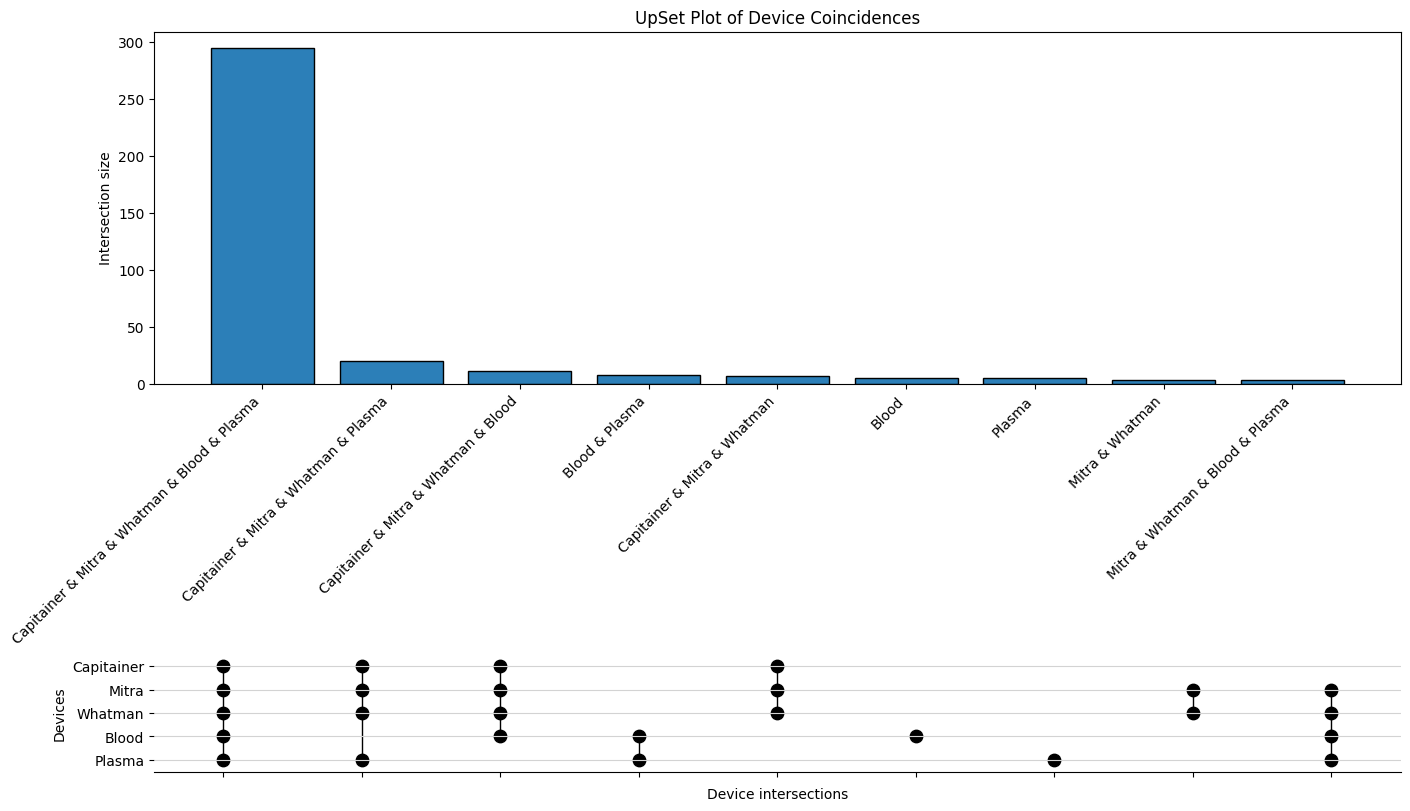

In [23]:
import itertools
import matplotlib.pyplot as plt

# Build the device sets from the HUMAN1 dataframe annotations
device_sets = {
    name: set(df_human1.loc[df_human1[name] == True].index.tolist())
    for name in devices.keys()
}
device_names = list(device_sets.keys())

# Compute exclusive intersections for all device combinations
intersection_counts = {}
for r in range(1, len(device_names) + 1):
    for combo in itertools.combinations(device_names, r):
        current = set.intersection(*(device_sets[name] for name in combo))
        for other_name in device_names:
            if other_name not in combo:
                current = current - device_sets[other_name]
        if current:
            intersection_counts[combo] = len(current)

# Keep the most relevant overlaps at the top
sorted_items = sorted(intersection_counts.items(), key=lambda item: item[1], reverse=True)
top_items = sorted_items[:15]

if top_items:
    combos, counts = zip(*top_items)
    labels = [' & '.join(combo) for combo in combos]
    fig, (ax_bar, ax_matrix) = plt.subplots(
        2, 1, figsize=(14, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        constrained_layout=True
    )

    ax_bar.bar(range(len(counts)), counts, color='#2c7fb8', edgecolor='black')
    ax_bar.set_ylabel('Intersection size')
    ax_bar.set_title('UpSet Plot of Device Coincidences')
    ax_bar.set_xticks(range(len(labels)))
    ax_bar.set_xticklabels(labels, rotation=45, ha='right')

    ax_matrix.set_xlim(-0.5, len(counts) - 0.5)
    ax_matrix.set_ylim(-0.5, len(device_names) - 0.5)
    ax_matrix.set_yticks(range(len(device_names)))
    ax_matrix.set_yticklabels(device_names)
    ax_matrix.set_xticks(range(len(labels)))
    ax_matrix.set_xticklabels([])

    for x, combo in enumerate(combos):
        active_rows = [device_names.index(name) for name in combo]
        ax_matrix.scatter([x] * len(active_rows), active_rows, s=80, color='black')
        if len(active_rows) > 1:
            ax_matrix.plot([x, x], [min(active_rows), max(active_rows)], color='black', linewidth=1)

    for y in range(len(device_names)):
        ax_matrix.hlines(y, -0.5, len(counts) - 0.5, color='lightgray', linewidth=0.8)

    ax_matrix.invert_yaxis()
    ax_matrix.set_xlabel('Device intersections')
    ax_matrix.set_ylabel('Devices')
    ax_matrix.spines['top'].set_visible(False)
    ax_matrix.spines['right'].set_visible(False)
    ax_matrix.spines['left'].set_visible(False)

    plt.show()
else:
    print('No device coincidences found to plot.')

# 2- Model application
From here we will be using the graph  directly and showing results on the human1 graph

In [9]:
import networkx as nx
from etc.hamiltonian import Hamiltonian
from etc.coverage import Coverage

### Define H object and parameters of G

In [10]:
graph = nx.read_gml(graph_gml)
H = Hamiltonian(graph)
mu = H.mu_density_aware(graph)
gamma = H.gamma_balancer(mu=mu)
n = graph.number_of_nodes()
coverage = Coverage(H)

In [11]:
# Get filtered dataframe for Capitainer and match with graph labels
capitainer_filtered = df_human1[df_human1.Capitainer == True]

# Get the metabolite IDs from the filtered dataframe (using index as HUMAN1_ID)
capitainer_ids = set(capitainer_filtered.index.tolist())

# Get all graph node labels
graph_nodes = list(graph.nodes())

# Create mapping of graph labels to indices
node_to_index = {node: idx for idx, node in enumerate(graph_nodes)}

# Create S_idx as a binary mask vector (1 where node is in Capitainer, 0 elsewhere)
S_idx = np.zeros(len(graph_nodes), dtype=int)
for node_id in capitainer_ids:
    if node_id in node_to_index:
        S_idx[node_to_index[node_id]] = 1

print(f"Total nodes in graph: {len(graph_nodes)}")
print(f"Capitainer metabolites matched in graph: {np.sum(S_idx)}")
print(f"S_idx shape: {S_idx.shape}")


Total nodes in graph: 3240
Capitainer metabolites matched in graph: 75
S_idx shape: (3240,)


In [12]:
energy_value_capitainer = coverage.energy(S_idx=S_idx, mu=mu, gamma=gamma)
print(f"Energy of the Capitainer subset: {energy_value_capitainer}")

Energy of the Capitainer subset: 11930.020488216529


In [13]:
energy_values_capitainer, min_energy_capitainer, max_energy_capitainer = coverage.sample_energy(
    n=n,k=75, mu=mu, gamma=gamma,n_samples=3000)

KeyboardInterrupt: 

In [ ]:
max_energy_capitainer, min_energy_capitainer

(array([1, 1, 1, ..., 1, 1, 1], shape=(3240,)),
 array([1, 1, 1, ..., 1, 1, 1], shape=(3240,)))

In [26]:
coverage.energy(S_idx=max_energy_capitainer, mu=mu, gamma=gamma)

0.0

In [11]:
energy_values_mitra, min_energy_mitra, max_energy_mitra = C.sample_energy(
    n=n,k=k_mitra, mu=mu, gamma=gamma,n_samples=1000)

In [20]:
# Create S_idx masks for all devices
device_masks = {}
device_energies = {}

for device_name in devices.keys():
    device_filtered = df_human1[df_human1[device_name] == True]
    device_ids = set(device_filtered.index.tolist())
    
    # Create binary mask
    S_idx_device = np.zeros(len(graph_nodes), dtype=int)
    for node_id in device_ids:
        if node_id in node_to_index:
            S_idx_device[node_to_index[node_id]] = 1
    
    device_masks[device_name] = S_idx_device
    device_energies[device_name] = coverage.energy(S_idx=S_idx_device, mu=mu, gamma=gamma)
    
    print(f"{device_name}: {np.sum(S_idx_device)} nodes, Energy = {device_energies[device_name]:.6f}")


Capitainer: 75 nodes, Energy = 11930.020488
Mitra: 77 nodes, Energy = 12309.457285
Whatman: 77 nodes, Energy = 12309.457285
Blood: 70 nodes, Energy = 11325.334631
Plasma: 73 nodes, Energy = 11290.264078


In [15]:
energy = coverage.sample_energy_variable_k(n=n, k_min=69,k_max=76
                                  ,mu=mu, gamma=gamma, n_samples=5000)

In [ ]:
energy_values_whatman, min_energy_whatman, max_energy_whatman = coverage.sample_energy(
    n=n,k=77, mu=mu, gamma=gamma,n_samples=1000)

In [ ]:
energy_values_blood, min_energy_blood, max_energy_blood = coverage.sample_energy(
    n=n,k=70, mu=mu, gamma=gamma,n_samples=1000)

In [ ]:
energy_values_plasma, min_energy_plasma, max_energy_plasma = coverage.sample_energy(
    n=n,k=73, mu=mu, gamma=gamma,n_samples=1000)

# 3- Visualization

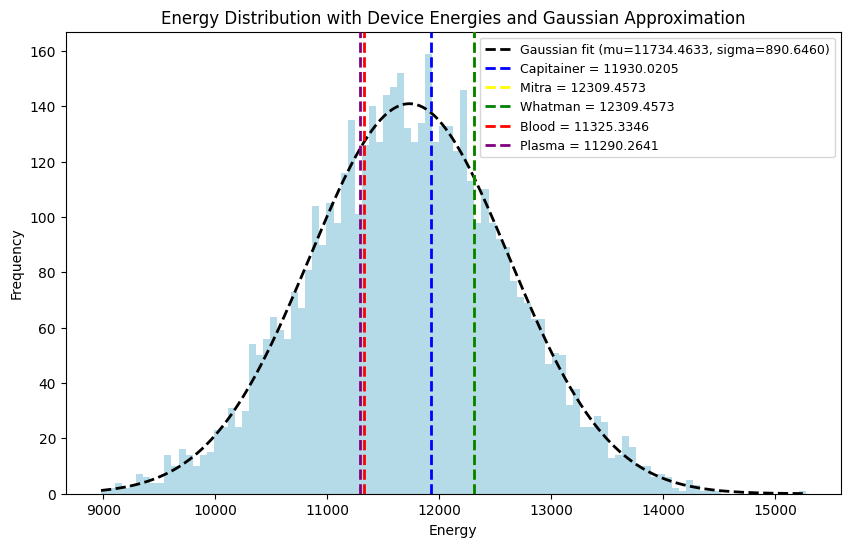

In [41]:
import matplotlib.pyplot as plt

# Use sampled distribution from variable-k sampling (energy[0]) if available
dist = energy[0] if isinstance(energy, (list, tuple)) else energy_values_capitainer

# Compute histogram bins and counts for precise control
counts, bins = np.histogram(dist, bins=100)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(10, 6))
# Light-blue bars with no contour
plt.bar(bin_centers, counts, width=bin_width, color='lightblue', edgecolor='none', align='center', alpha=0.9)

# Gaussian approximation (scaled to histogram counts)
mu = np.mean(dist)
sigma = np.std(dist)
x = np.linspace(bins[0], bins[-1], 500)
pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
pdf_scaled = pdf * len(dist) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label=f'Gaussian fit (mu={mu:.4f}, sigma={sigma:.4f})')

# Colors for the five devices
colors = {
    'Capitainer': 'blue',
    'Mitra': 'yellow',
    'Whatman': 'green',
    'Blood': 'red',
    'Plasma': 'purple'
}

# Plot vertical lines for each device energy; emphasize Blood and Plasma
for name, color in colors.items():

    val = device_energies[name]

    plt.axvline(val, color=color, linestyle='--', linewidth=2, label=f'{name} = {val:.4f}', zorder=8)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distribution with Device Energies and Gaussian Approximation')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)
plt.savefig(f'{data_folder}/figs/energy_distribution_with_devices.png', dpi=400, bbox_inches='tight')
plt.show()
